## Spike Inference: Derivative and Threshold

_Method_: First derivative of dF/F deNoised for 1 session and use Z score to threshold

In [6]:
% load data
addpath('matlab','data')
load('calcium_data.mat')
load('stimuli_info.mat')
load ('data_stimsorted.mat')

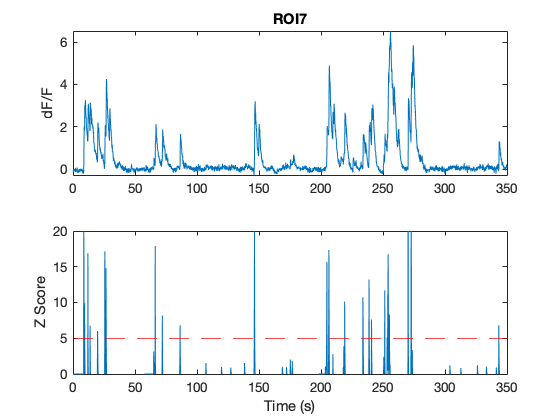

In [27]:
thresh = 5;
plot_zscore(data,frameRate,7, thresh);

Using a Z-score threshold of 5 seems to work well for most ROIs as shown in the trace above. 
However it misses some of the events in movies where the cell is more active:

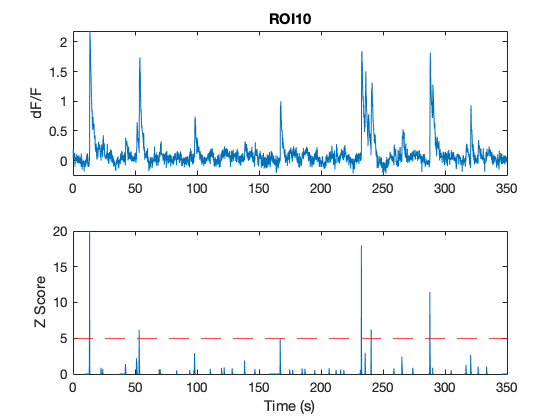

In [26]:
plot_zscore(data,frameRate,10, thresh);

and it captures noise for traces where there is sparse firing

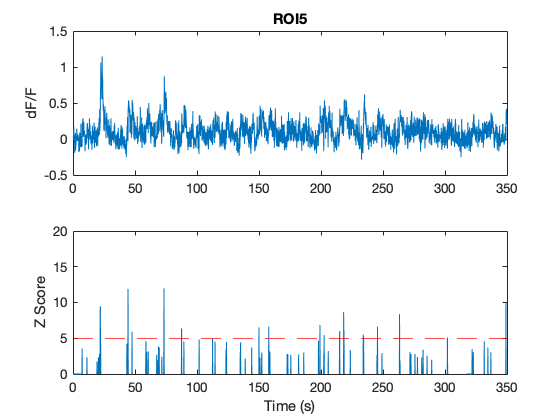

In [23]:
plot_zscore(data,frameRate,ROInum, thresh);

ROIs with sparse firing have smaller std devs while more active ROIs have larger std devs resulting in a poor selection of threshold based on z score. After looking at the raw values for std devs for many ROIS, $\sigma = 0.25$ was the best choice, corresponding to a z score of ~ 5. 

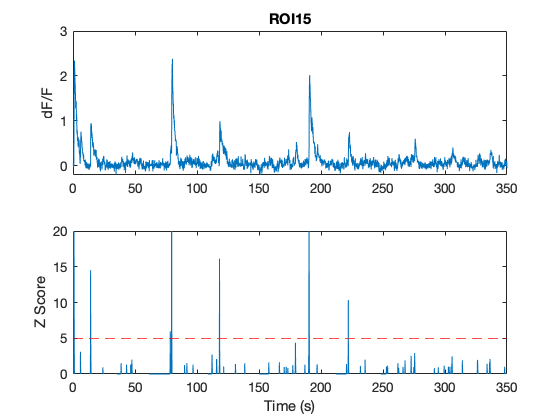

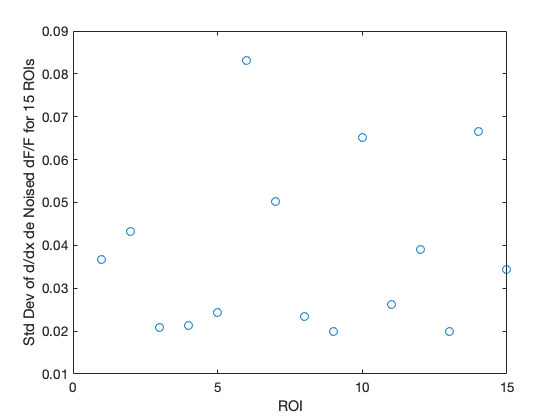

In [29]:
% Plot sigmas for first 15 ROIs 
sigmas = ones(15,1);
for i = 1:15
[z, mu, sigma] = plot_zscore(data,frameRate,i, thresh);
sigmas(i) = sigma;
end
figure(2)
plot(sigmas, 'o')
xlabel('ROI')
ylabel ('Std Dev of d/dx de Noised dF/F for 15 ROIs')

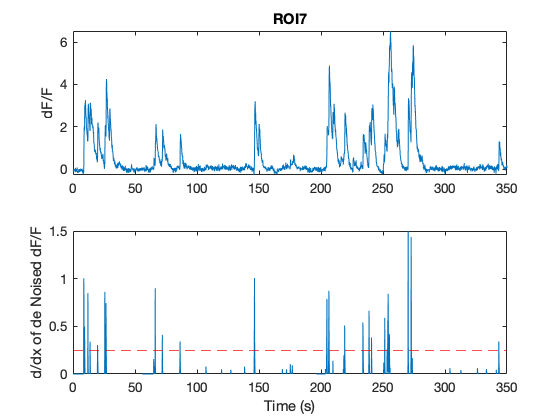

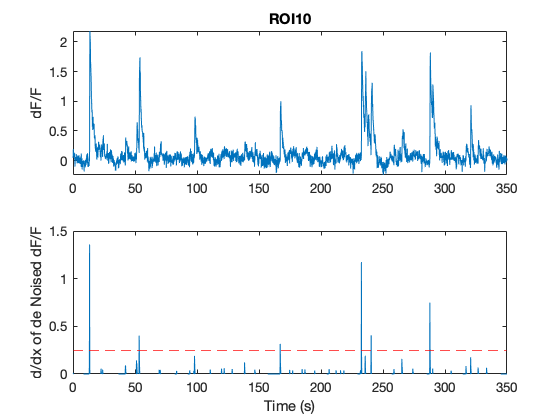

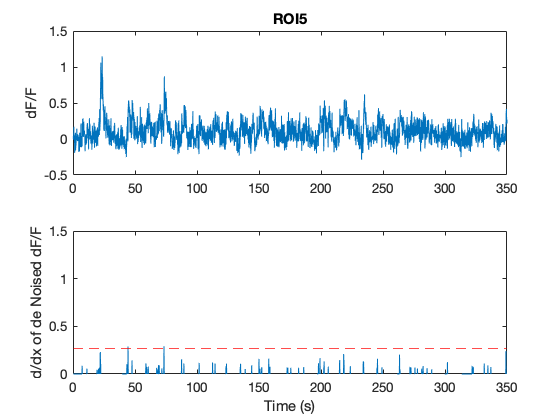

In [31]:
plot_thrld(data, frameRate,7, 0.25)
figure(2)
plot_thrld(data, frameRate,10, 0.25)
figure(3)
plot_thrld(data, frameRate,5, 0.25)